### Support Vector Machine (SVM)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    precision_score,
    recall_score,
    f1_score,
)

In [2]:
data_url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/crop_recommendation/train_set_label.csv"
df = pd.read_csv(data_url)

print(df.head()) 

       N      P      K  temperature   humidity        ph    rainfall      crop
0   17.0  136.0  196.0    23.871923  90.499390  5.882156  103.054809     apple
1   49.0   69.0   82.0    18.315615  15.361435  7.263119   81.787105  chickpea
2   74.0   49.0   38.0    23.314104  71.450905  7.488014  164.497037      jute
3  104.0   35.0   28.0    27.510061  50.666872  6.983732  143.995555    coffee
4   23.0   72.0   84.0    19.020613  17.131591  6.920251   79.926981  chickpea


In [3]:
feature_col = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X = df[feature_col]
y = df['crop']

#label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [4]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [5]:
X_train
# y_train

,N,P,K,temperature,humidity,ph,rainfall
1068,68.000000,69.000000,52.000000,25.654923,92.745016,6.813383,52.954779
1019,60.000000,49.000000,44.000000,20.775761,84.497744,6.244841,240.081065
693,20.000000,77.000000,23.000000,34.872487,38.837860,5.180272,148.250279
994,20.000000,74.000000,16.000000,36.043537,43.614441,4.759490,159.893865
1622,71.000000,52.000000,18.000000,25.107874,55.977328,5.790770,78.160777
...,...,...,...,...,...,...,...
321,32.000000,11.000000,31.000000,25.068720,93.314104,6.205932,134.841907
1215,37.000000,70.000000,25.000000,19.731369,24.894874,5.819404,84.063541
1012,89.000000,25.000000,54.000000,24.693689,85.569676,6.353107,48.993908
1079,117.116007,30.116007,32.674011,26.983865,61.788008,6.353415,183.948969


In [6]:
X_train.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000
mean,50.558649,53.443733,48.063172,25.632286,71.524225,6.493445,103.854957
std,36.795041,33.263771,50.547857,5.039335,22.215540,0.781609,55.502902
min,0.000000,5.000000,5.000000,9.467960,14.273280,3.525366,20.360011
25%,22.000000,27.000000,20.436428,22.712028,60.052333,5.999508,64.853498
50%,37.000000,52.000000,31.075086,25.655229,80.537643,6.418436,94.707894
75%,84.568728,68.000000,49.000000,28.543408,89.987078,6.943648,129.026885
max,136.000000,145.000000,205.000000,42.936054,99.981876,9.935091,298.560117


In [7]:
# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


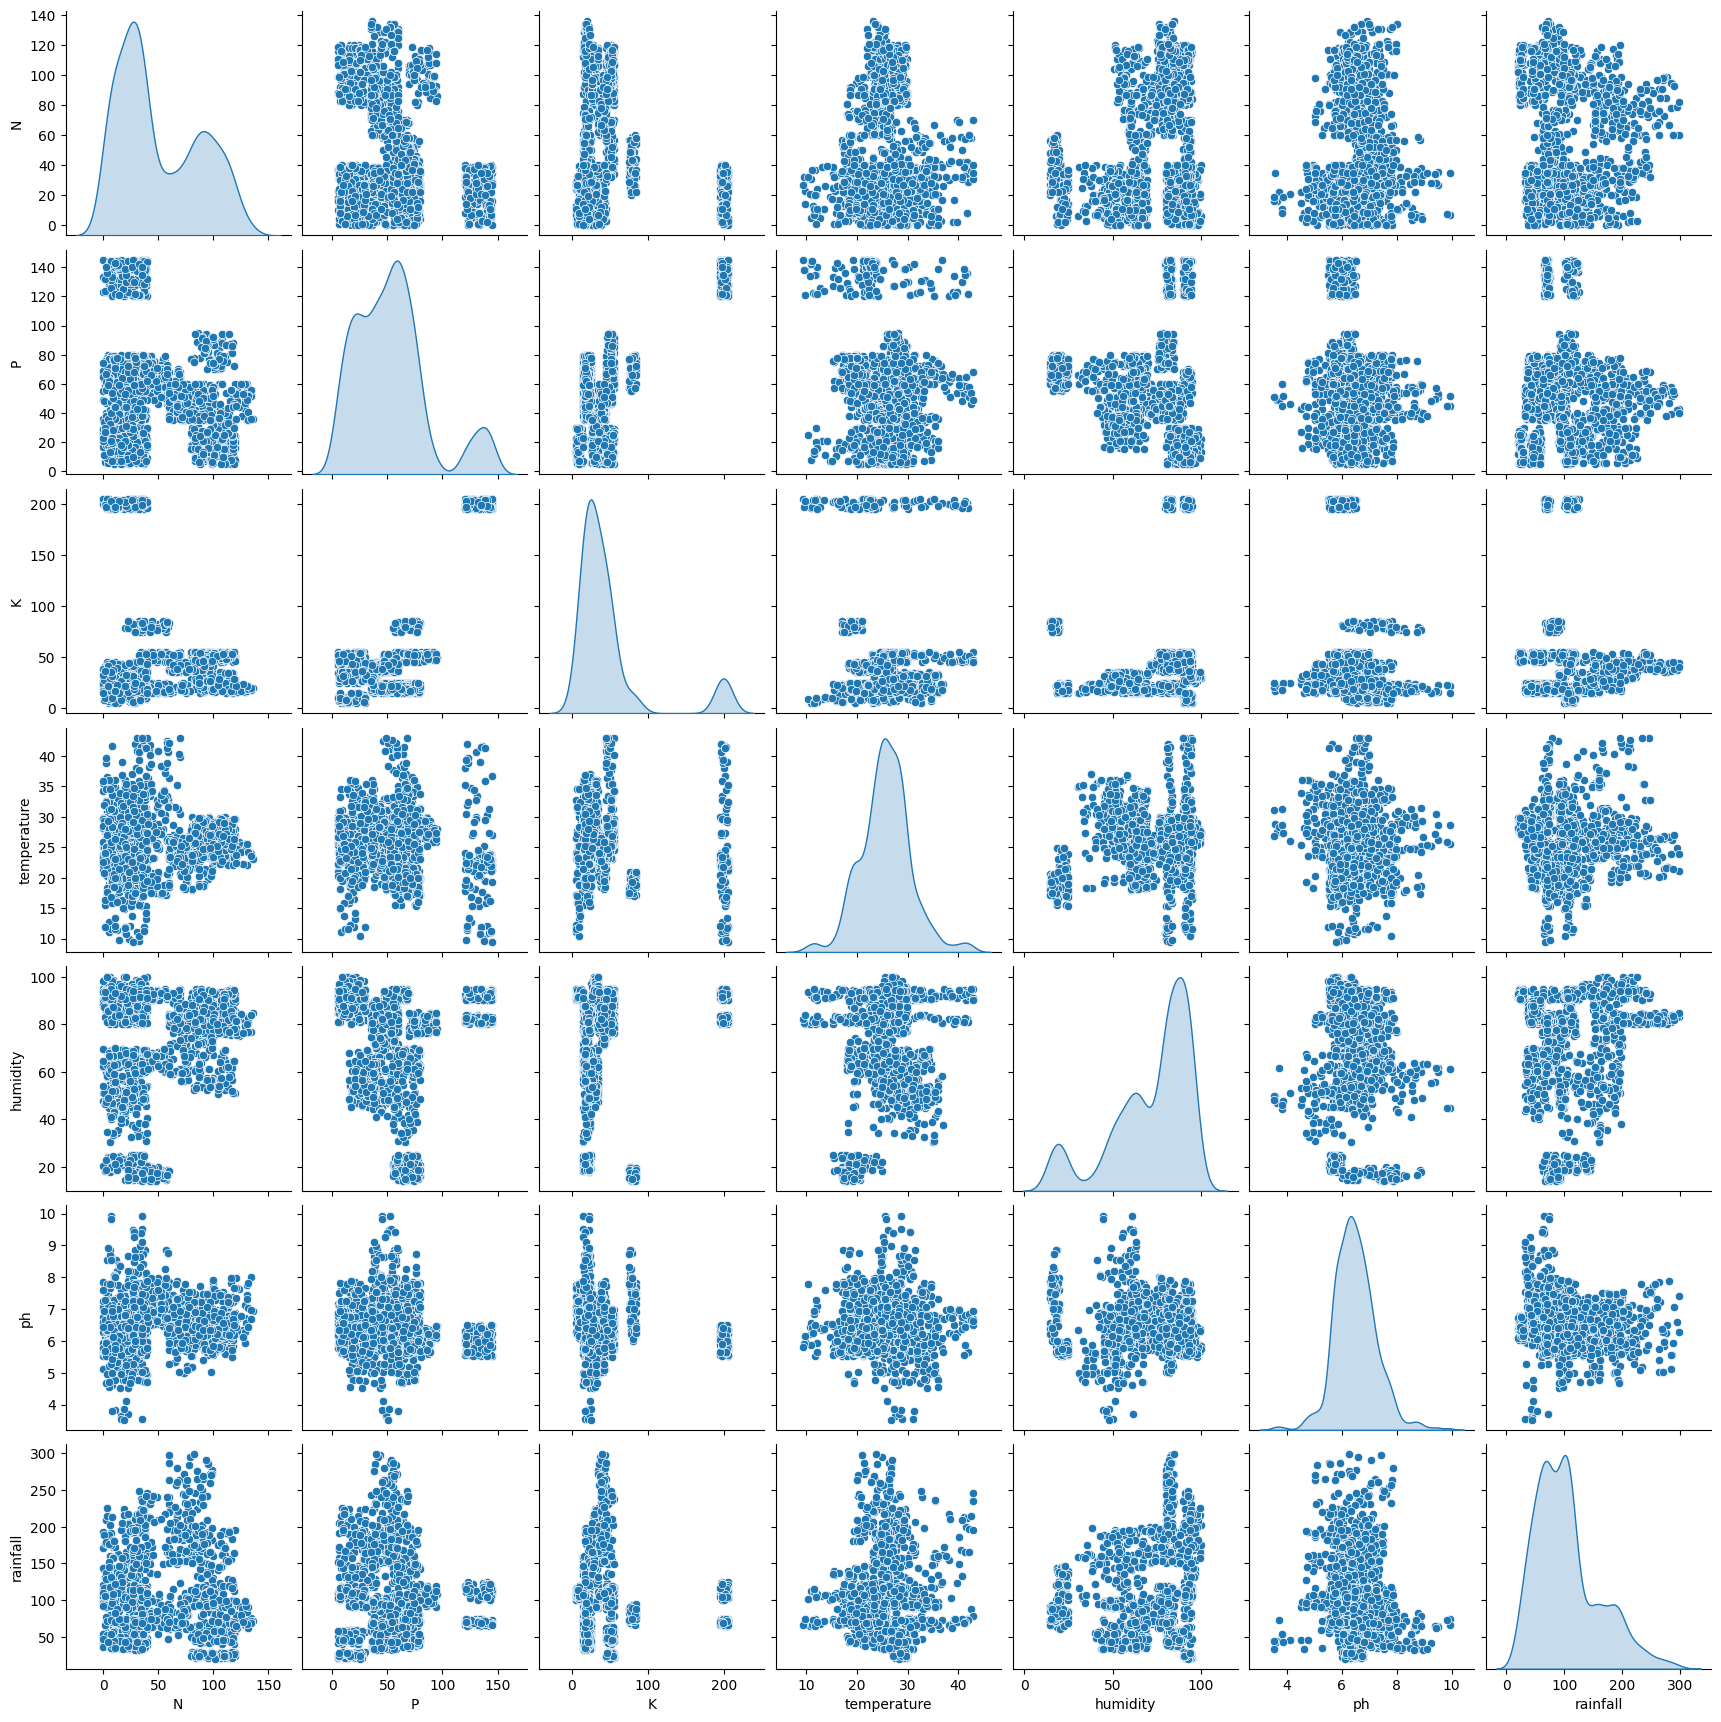

In [8]:
# Pairplot - Shows all pairwise relationships between all features
# This creates a grid of scatter plots showing relationships between every pair of features
feature_col = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Method 1: Basic pairplot (all features)
sns.pairplot(df[feature_col], diag_kind='kde')
plt.show()

# Method 2: Pairplot colored by crop type (helps identify patterns by crop)
# Uncomment below to see relationships colored by crop type
# sns.pairplot(df, vars=feature_col, hue='crop', diag_kind='kde', height=2.5)
# plt.suptitle('Pairwise Relationships Colored by Crop Type', y=1.02, fontsize=16)
# plt.tight_layout()
# plt.show()

<Axes: >

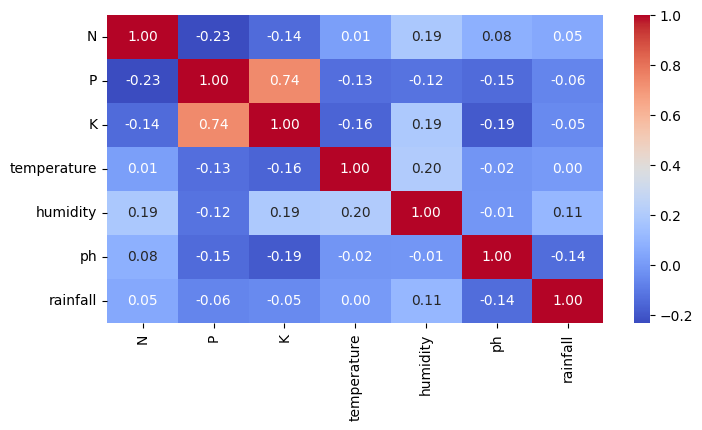

In [9]:
#corr matrix 
#+1 -> +ve corr
#-1 -> -ve corr
# 0 ->  no corr

corr = df[feature_col].corr()
# Visualize correlation matrix as a heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

In [10]:
#baseline svm model

svm_baseline = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

svm_baseline.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [11]:
y_pred_baseline = svm_baseline.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline, average='weighted')
recall = recall_score(y_test, y_pred_baseline, average='weighted')
f1 = f1_score(y_test, y_pred_baseline, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.9909
Precision: 0.9924
Recall: 0.9909
F1 Score: 0.9908


In [12]:
#hyperparameter tuning with gridsearchcv

param_grid= {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['poly', 'rbf', 'linear', 'sigmoid']
}

grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

y_pred_final = best_model.predict(X_test_scaled)

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, average='weighted')
recall_final = recall_score(y_test, y_pred_final, average='weighted')
f1_final = f1_score(y_test, y_pred_final, average='weighted')

print(f"Accuracy final: {accuracy_final:.4f}")
print(f"Precision final: {precision_final:.4f}")
print(f"Recall final: {recall_final:.4f}")
print(f"F1 Score final: {f1_final:.4f}")


Fitting 5 folds for each of 80 candidates, totalling 400 fits


Best params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV score: 0.9894
Accuracy final: 0.9879
Precision final: 0.9896
Recall final: 0.9879
F1 Score final: 0.9878


In [14]:
import joblib
from pathlib import Path

model_obj = globals().get("best_model")
output_path = Path("../../models/svm.pkl")
output_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model_obj, output_path)
print(f"Saved model to: {output_path.resolve()}")

Saved model to: /media/kushagra/DATA/notebook/crop-recommendation-ml-system/models/svm.pkl


In [15]:
sample_input = [[17.0,  136.0,  196.0,    23.871923,  90.499390,  5.882156,  103.054809]]  # N, P, K, temperature, humidity, ph, rainfall
prediction = best_model.predict(sample_input)
print(f"Predicted crop: {le.inverse_transform([prediction[0]])[0]}")

Predicted crop: mothbeans
